TypeError: 'Axes' object is not subscriptable

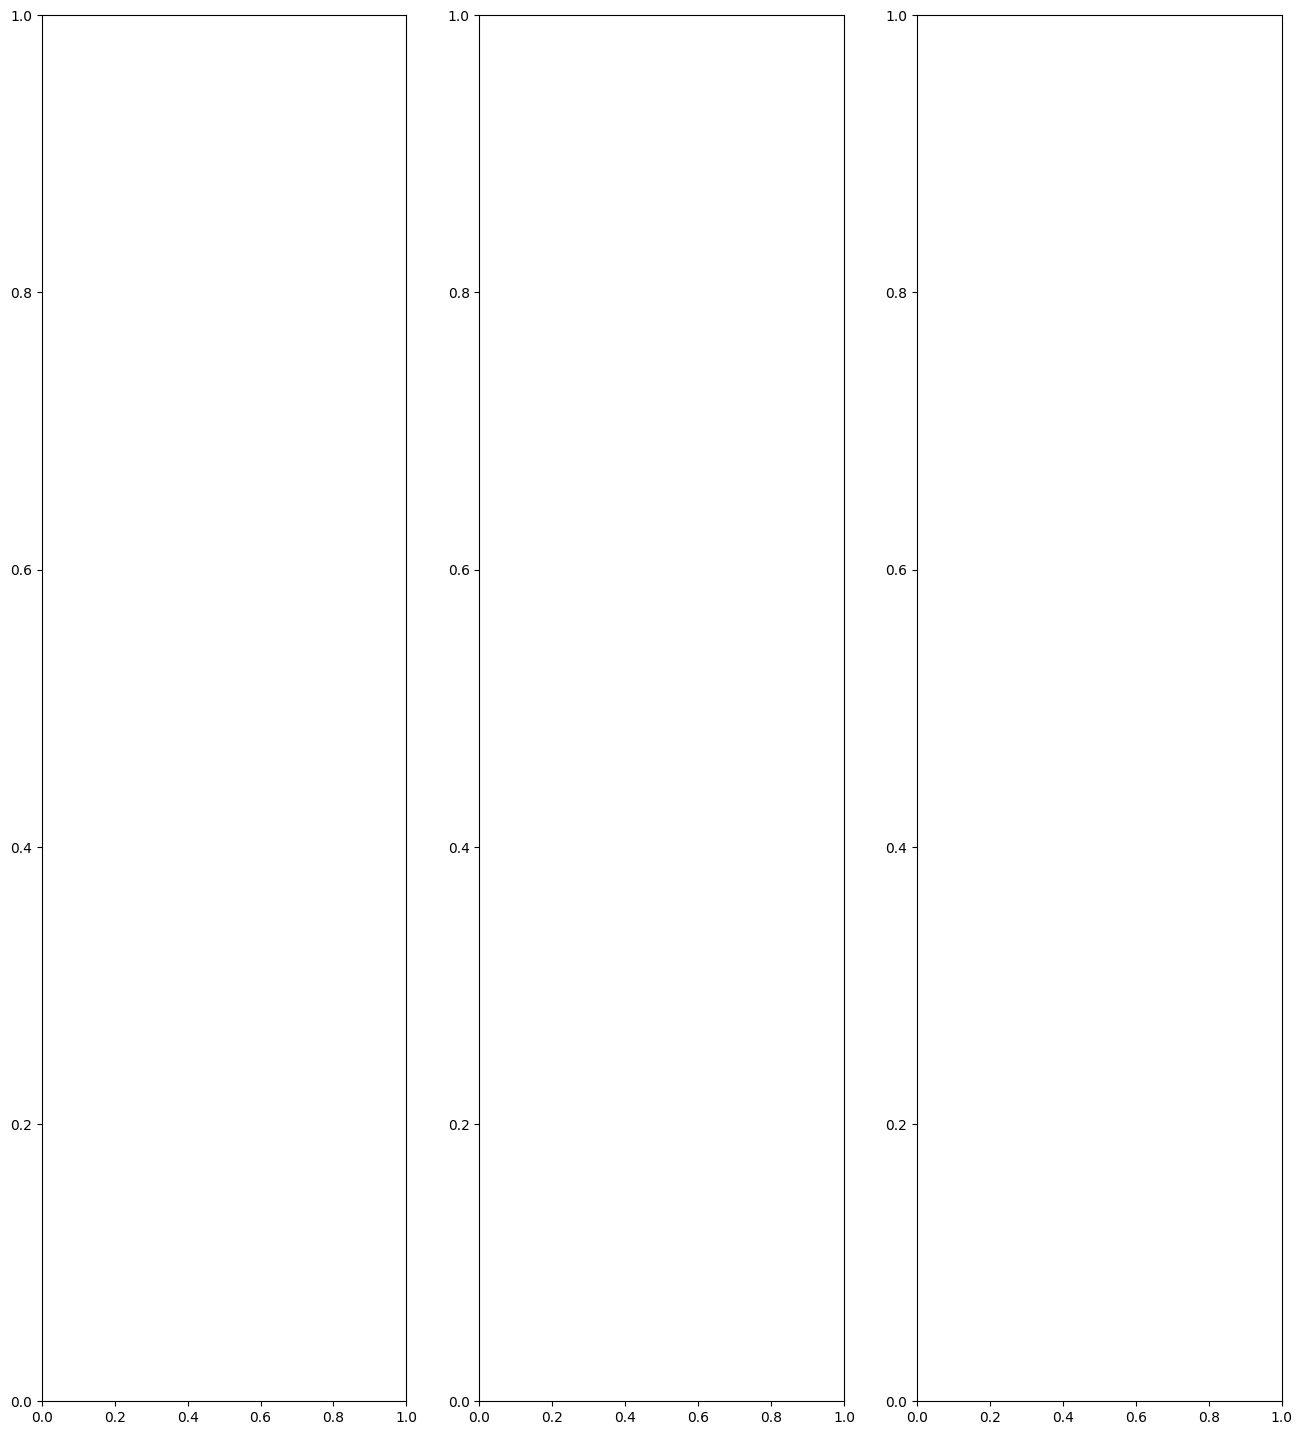

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Define the file paths
file_paths = [
    "3_checkingHumanity/data/gemini2FlashIterationsWithScores.json",
    "3_checkingHumanity/data/gemini15ProIterationsWithScores.json",
    "3_checkingHumanity/data/GPT4oIterationsWithScores.json"
]

def process_file(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    iterations_data = {}
    original_scores = {"zerogpt": [], "roberta": []}
    summarized_scores = {"zerogpt": [], "roberta": []}
    
    def safe_append(score_list, value):
        if value is not None:
            score_list.append(value)
    
    for entry in data:
        safe_append(original_scores["zerogpt"], entry["original_text_metrics"]["detection_scores"].get("zerogpt"))
        safe_append(original_scores["roberta"], entry["original_text_metrics"]["detection_scores"].get("roberta"))
        
        safe_append(summarized_scores["zerogpt"], entry["summarized_text_metrics"]["detection_scores"].get("zerogpt"))
        safe_append(summarized_scores["roberta"], entry["summarized_text_metrics"]["detection_scores"].get("roberta"))
        
        for iteration in entry["iterations"]:
            iteration_num = iteration["iteration_number"]
            if iteration_num not in iterations_data:
                iterations_data[iteration_num] = {"zerogpt": [], "roberta": []}
            safe_append(iterations_data[iteration_num]["zerogpt"], iteration["detection_scores"].get("zerogpt"))
            safe_append(iterations_data[iteration_num]["roberta"], iteration["detection_scores"].get("roberta"))
    
    return original_scores, summarized_scores, iterations_data

datasets = [process_file(file_path) for file_path in file_paths]

def plot_scores(fig, axes, method, color, datasets, titles):
    for i, (original_scores, summarized_scores, iterations_data) in enumerate(datasets):
        ax = axes[i][0]
        positions = [1, 2]
        labels = ["Original", "Summarized"]
        data_to_plot = [original_scores[method], summarized_scores[method]]
        means = [np.mean(summarized_scores[method])]
        iteration_numbers = [2]
        pos_index = 3
        
        for iteration_num, scores in sorted(iterations_data.items()):
            positions.append(pos_index)
            labels.append(f"Iter {iteration_num}")
            data_to_plot.append(scores[method])
            means.append(np.mean(scores[method]))
            iteration_numbers.append(pos_index)
            pos_index += 1
        
        ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, boxprops=dict(facecolor=color))
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("Detection Scores")
        ax.set_title(f"{titles[i]} - {method.capitalize()}")
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.axvline(x=1.5, color='black', linestyle='-', linewidth=0.8)
        
        coeffs = np.polyfit(iteration_numbers, means, 2)
        poly_eq = np.poly1d(coeffs)
        fit_x = np.linspace(min(iteration_numbers), max(iteration_numbers), 100)
        fit_y = poly_eq(fit_x)
        ax.plot(fit_x, fit_y, linestyle="--", color="black")

# Create figure for ZeroGPT
titles = ["Gemini2Flash", "Gemini15Pro", "GPT4o"]
fig1, axes1 = plt.subplots(nrows=1, ncols=3, figsize=(16, 18), sharex=True)
plot_scores(fig1, axes1, "zerogpt", "lightblue", datasets, titles)
plt.tight_layout()
plt.show()

# Create figure for RoBERTa
fig2, axes2 = plt.subplots(nrows=1, ncols=3, figsize=(16, 18), sharex=True)
plot_scores(fig2, axes2, "roberta", "lightcoral", datasets, titles)
plt.tight_layout()
plt.show()


In [6]:
from genson import SchemaBuilder
import json

file_path = "3_checkingHumanity/data/gemini2FlashIterationsWithScores.json"

with open(file_path, "r") as f:
    data = json.load(f)

# Generate schema
builder = SchemaBuilder()
builder.add_object(data)

print(json.dumps(builder.to_schema(), indent=4))


{
    "$schema": "http://json-schema.org/schema#",
    "type": "array",
    "items": {
        "type": "object",
        "properties": {
            "id": {
                "type": "integer"
            },
            "original_text": {
                "type": "string"
            },
            "summarized_text": {
                "type": "string"
            },
            "iterations": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "iteration_number": {
                            "type": "integer"
                        },
                        "rewritten_text": {
                            "type": "string"
                        },
                        "detection_scores": {
                            "type": "object",
                            "properties": {
                                "zerogpt": {
                                    "type": [
          